# Notebook 00: Environment Setup

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase1/00_environment_setup.ipynb)

---

## Learning Objectives

By the end of this notebook, you will:
1. Have a fully configured environment for 3DGS learning
2. Understand the key dependencies and their purposes
3. Verify that GPU acceleration is working
4. Be ready to start the 3DGS tutorials

**Estimated Time**: 30 minutes

---

## 1. Environment Detection

First, let's detect what environment we're running in and configure accordingly.

In [1]:
import os
import sys

# Detect environment
IN_COLAB = 'google.colab' in sys.modules
IN_JUPYTER = 'ipykernel' in sys.modules

print("Environment Detection")
print("=" * 40)
print(f"Running in Google Colab: {IN_COLAB}")
print(f"Running in Jupyter: {IN_JUPYTER}")
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

Environment Detection
Running in Google Colab: False
Running in Jupyter: True
Python version: 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]
Python executable: /home/user/miniconda3/bin/python


## 2. Colab-Specific Setup

If running in Google Colab, we need to clone the repository and install dependencies.

In [2]:
if IN_COLAB:
    print("Setting up for Google Colab...")
    
    # Clone the repository
    if not os.path.exists('3DGS-from-scratch'):
        !git clone https://github.com/ChunLI-666/3DGS-from-scratch.git
    
    # Change to project directory
    os.chdir('3DGS-from-scratch')
    
    # Install dependencies
    !pip install -q plotly ipywidgets pyvista
    
    # Add src to path
    sys.path.insert(0, os.path.join(os.getcwd(), 'src'))
    
    print("Colab setup complete!")
else:
    # For local setup, ensure we're in the right directory
    # and src is in the path
    project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath('.'))))
    if os.path.exists(os.path.join(project_root, 'src')):
        sys.path.insert(0, os.path.join(project_root, 'src'))
    
    # Try to find src directory
    for path in ['../../src', '../src', './src', '../../']:
        full_path = os.path.abspath(path)
        if os.path.exists(os.path.join(full_path, 'gaussian')):
            sys.path.insert(0, full_path)
            break

## 3. Check Core Dependencies

Let's verify that all required packages are installed.

In [3]:
def check_package(package_name, import_name=None):
    """Check if a package is installed and return its version."""
    import_name = import_name or package_name
    try:
        module = __import__(import_name)
        version = getattr(module, '__version__', 'unknown')
        return True, version
    except ImportError:
        return False, None

# Core packages to check
packages = [
    ('numpy', 'numpy'),
    ('torch', 'torch'),
    ('torchvision', 'torchvision'),
    ('matplotlib', 'matplotlib'),
    ('plotly', 'plotly'),
    ('scipy', 'scipy'),
    ('PIL', 'PIL'),
    ('ipywidgets', 'ipywidgets'),
    ('tqdm', 'tqdm'),
]

print("Dependency Check")
print("=" * 50)
print(f"{'Package':<20} {'Status':<10} {'Version'}")
print("-" * 50)

all_installed = True
for package_name, import_name in packages:
    installed, version = check_package(package_name, import_name)
    status = "OK" if installed else "MISSING"
    version_str = version if version else "N/A"
    print(f"{package_name:<20} {status:<10} {version_str}")
    if not installed:
        all_installed = False

print("-" * 50)
if all_installed:
    print("All core dependencies are installed!")
else:
    print("Some dependencies are missing. Please install them.")

Dependency Check
Package              Status     Version
--------------------------------------------------
numpy                OK         2.4.2
torch                OK         2.10.0+cu128
torchvision          OK         0.25.0+cu128
matplotlib           OK         3.10.8
plotly               OK         6.5.2
scipy                OK         1.15.3
PIL                  OK         11.2.1
ipywidgets           OK         8.1.8
tqdm                 OK         4.67.3
--------------------------------------------------
All core dependencies are installed!


## 4. GPU and CUDA Check

3DGS benefits significantly from GPU acceleration. Let's check your GPU status.

In [4]:
import torch

print("GPU and CUDA Information")
print("=" * 50)

# PyTorch CUDA support
print(f"\nPyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"\nGPU {i}: {props.name}")
        print(f"  - Compute Capability: {props.major}.{props.minor}")
        print(f"  - Total Memory: {props.total_memory / 1e9:.1f} GB")
        print(f"  - Multi-Processor Count: {props.multi_processor_count}")
    
    # Memory info for current GPU
    print(f"\nCurrent GPU Memory:")
    print(f"  - Allocated: {torch.cuda.memory_allocated() / 1e6:.1f} MB")
    print(f"  - Cached: {torch.cuda.memory_reserved() / 1e6:.1f} MB")
else:
    print("\nNo GPU available. Training will be slow.")
    print("For best experience, use a machine with NVIDIA GPU.")

GPU and CUDA Information

PyTorch Version: 2.10.0+cu128
CUDA Available: True
CUDA Version: 12.8
cuDNN Version: 91002
Number of GPUs: 1

GPU 0: NVIDIA GeForce RTX 4090 Laptop GPU
  - Compute Capability: 8.9
  - Total Memory: 16.7 GB
  - Multi-Processor Count: 76

Current GPU Memory:
  - Allocated: 0.0 MB
  - Cached: 0.0 MB


## 5. Quick GPU Test

Let's run a quick test to ensure GPU computation works correctly.

In [5]:
import time

def gpu_benchmark(size=5000):
    """Simple benchmark comparing CPU and GPU matrix multiplication."""
    
    print(f"Matrix Multiplication Benchmark (size: {size}x{size})")
    print("=" * 50)
    
    # CPU benchmark
    a_cpu = torch.randn(size, size)
    b_cpu = torch.randn(size, size)
    
    start = time.time()
    c_cpu = torch.mm(a_cpu, b_cpu)
    cpu_time = time.time() - start
    print(f"CPU Time: {cpu_time*1000:.2f} ms")
    
    # GPU benchmark (if available)
    if torch.cuda.is_available():
        a_gpu = a_cpu.cuda()
        b_gpu = b_cpu.cuda()
        
        # Warm up
        _ = torch.mm(a_gpu, b_gpu)
        torch.cuda.synchronize()
        
        start = time.time()
        c_gpu = torch.mm(a_gpu, b_gpu)
        torch.cuda.synchronize()
        gpu_time = time.time() - start
        
        print(f"GPU Time: {gpu_time*1000:.2f} ms")
        print(f"Speedup: {cpu_time/gpu_time:.1f}x")
        
        # Verify correctness
        diff = (c_cpu - c_gpu.cpu()).abs().max()
        print(f"Max difference (should be ~0): {diff:.6f}")
    else:
        print("GPU not available for benchmark.")

gpu_benchmark()

Matrix Multiplication Benchmark (size: 5000x5000)
CPU Time: 264.52 ms
GPU Time: 12.46 ms
Speedup: 21.2x
Max difference (should be ~0): 0.001465


## 6. Test Visualization Libraries

Let's ensure our visualization tools are working correctly.

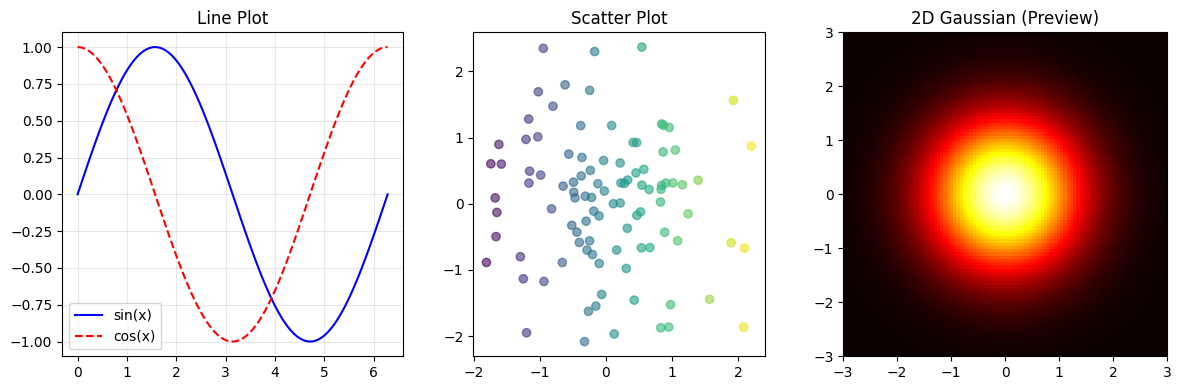

Matplotlib is working correctly!


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simple matplotlib test
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# 1. Line plot
x = np.linspace(0, 2*np.pi, 100)
axes[0].plot(x, np.sin(x), 'b-', label='sin(x)')
axes[0].plot(x, np.cos(x), 'r--', label='cos(x)')
axes[0].legend()
axes[0].set_title('Line Plot')
axes[0].grid(True, alpha=0.3)

# 2. Scatter plot
points = np.random.randn(100, 2)
axes[1].scatter(points[:, 0], points[:, 1], c=points[:, 0], cmap='viridis', alpha=0.6)
axes[1].set_title('Scatter Plot')
axes[1].set_aspect('equal')

# 3. Heatmap (preview of Gaussian)
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
zz = np.exp(-(xx**2 + yy**2) / 2)
axes[2].imshow(zz, extent=[-3, 3, -3, 3], cmap='hot', origin='lower')
axes[2].set_title('2D Gaussian (Preview)')

plt.tight_layout()
plt.show()

print("Matplotlib is working correctly!")

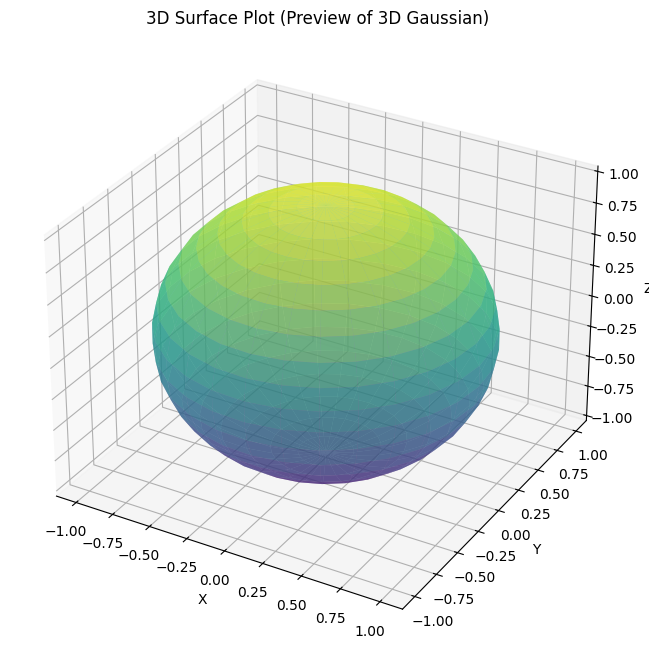

3D plotting is working correctly!


In [7]:
# Test 3D plotting
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a sphere (preview of 3D Gaussian)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 20)
x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z, alpha=0.6, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Surface Plot (Preview of 3D Gaussian)')

plt.show()

print("3D plotting is working correctly!")

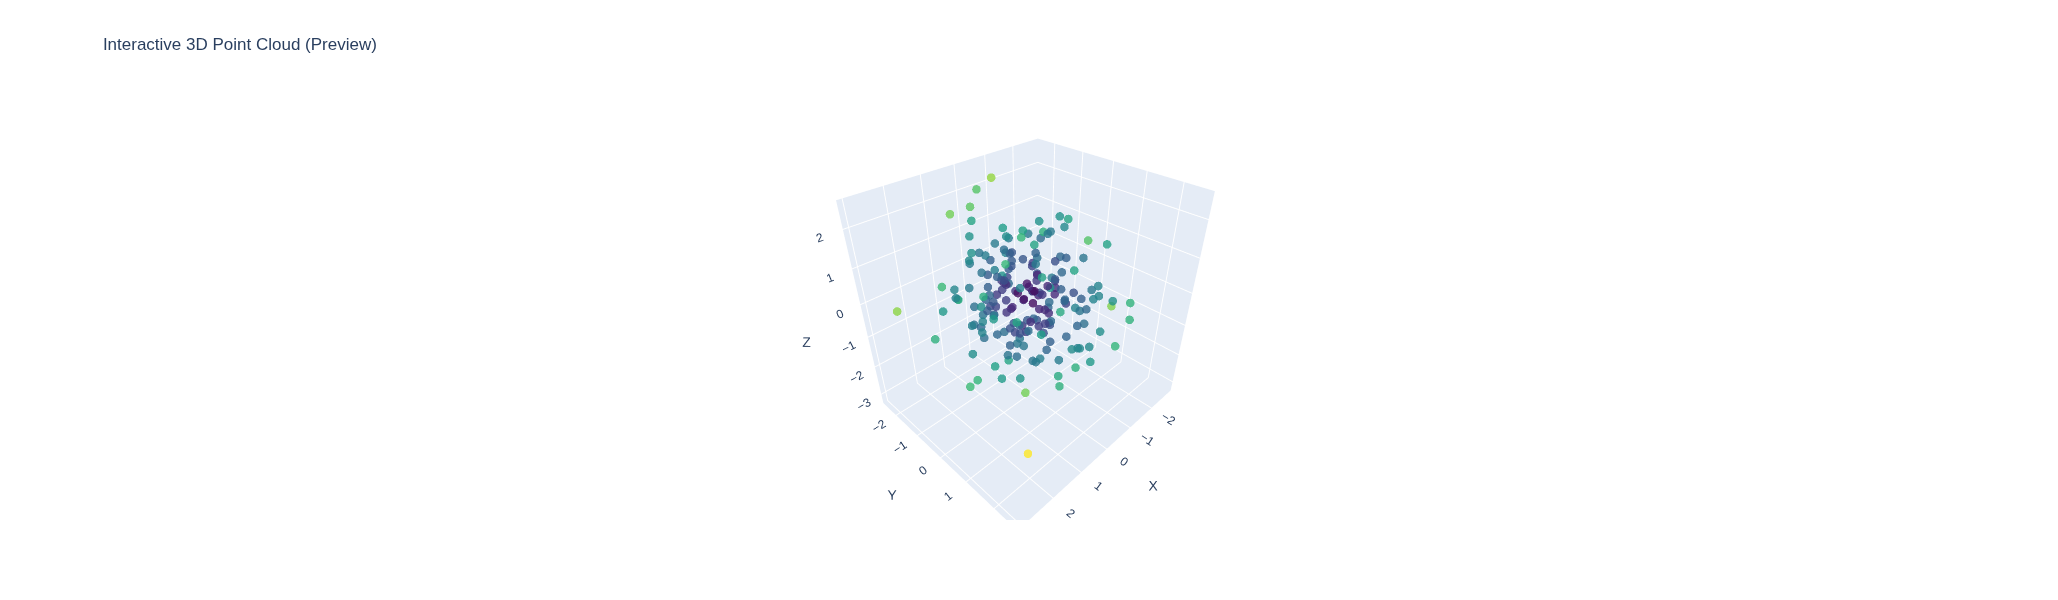

Plotly interactive plots are working!


In [8]:
# Test plotly for interactive plots
try:
    import plotly.graph_objects as go
    
    # Create interactive 3D scatter plot
    n_points = 200
    points_3d = np.random.randn(n_points, 3)
    colors = np.linalg.norm(points_3d, axis=1)
    
    fig = go.Figure(data=[go.Scatter3d(
        x=points_3d[:, 0],
        y=points_3d[:, 1],
        z=points_3d[:, 2],
        mode='markers',
        marker=dict(
            size=5,
            color=colors,
            colorscale='Viridis',
            opacity=0.8
        )
    )])
    
    fig.update_layout(
        title='Interactive 3D Point Cloud (Preview)',
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=700,
        height=600
    )
    
    fig.show()
    print("Plotly interactive plots are working!")
    
except Exception as e:
    print(f"Plotly test failed: {e}")
    print("Interactive plots may not work, but you can still use matplotlib.")

## 7. Test Tutorial Source Code

Let's verify that the tutorial source code is accessible.

In [9]:
# Try to import our custom modules
try:
    from gaussian.gaussian_model import Gaussian3D, GaussianModel
    from gaussian.covariance import quaternion_to_rotation_matrix, build_covariance_matrix
    from visualization.gaussian_viz import plot_2d_gaussian, plot_3d_ellipsoid
    
    print("Tutorial source code imported successfully!")
    
    # Quick test: create a simple Gaussian
    mean = torch.tensor([0.0, 0.0, 0.0])
    scaling = torch.tensor([1.0, 0.5, 0.3])
    rotation = torch.tensor([1.0, 0.0, 0.0, 0.0])  # Identity quaternion
    
    gaussian = Gaussian3D(mean, scaling, rotation)
    print(f"\nCreated test Gaussian: {gaussian}")
    
    cov = gaussian.get_covariance()
    print(f"\nCovariance matrix:\n{cov}")
    
except ImportError as e:
    print(f"Could not import tutorial modules: {e}")
    print("\nThis might happen if:")
    print("1. You're not in the project directory")
    print("2. The src path is not in sys.path")
    print("\nTrying to fix...")
    
    # Try alternative paths
    import os
    for path in ['../../src', '../src', '../../', '../', '.']:
        full_path = os.path.abspath(path)
        if os.path.exists(os.path.join(full_path, 'gaussian', 'gaussian_model.py')):
            sys.path.insert(0, full_path)
            print(f"Added to path: {full_path}")
            break
        elif os.path.exists(os.path.join(full_path, 'src', 'gaussian', 'gaussian_model.py')):
            sys.path.insert(0, os.path.join(full_path, 'src'))
            print(f"Added to path: {os.path.join(full_path, 'src')}")
            break

Tutorial source code imported successfully!

Created test Gaussian: Gaussian3D(
  mean=[0.0, 0.0, 0.0],
  scaling=[1.0, 0.5, 0.30000001192092896],
  rotation=[1.0, 0.0, 0.0, 0.0],
  opacity=1.0
)

Covariance matrix:
tensor([[1.0000, 0.0000, 0.0000],
        [0.0000, 0.2500, 0.0000],
        [0.0000, 0.0000, 0.0900]])


## 8. Environment Summary

Here's a summary of your environment setup.

In [10]:
import platform

print("\n" + "=" * 60)
print("          ENVIRONMENT SUMMARY")
print("=" * 60)

# System info
print("\n[System]")
print(f"  OS: {platform.system()} {platform.release()}")
print(f"  Python: {platform.python_version()}")
print(f"  Architecture: {platform.machine()}")

# PyTorch info
print("\n[PyTorch]")
print(f"  Version: {torch.__version__}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Key packages
print("\n[Key Packages]")
packages_to_show = ['numpy', 'scipy', 'matplotlib', 'plotly']
for pkg in packages_to_show:
    try:
        mod = __import__(pkg)
        print(f"  {pkg}: {mod.__version__}")
    except:
        print(f"  {pkg}: Not installed")

# Environment
print("\n[Environment]")
print(f"  Running in Colab: {IN_COLAB}")
print(f"  Working Directory: {os.getcwd()}")

print("\n" + "=" * 60)
print("  Environment setup complete! Ready to learn 3DGS!")
print("=" * 60)


          ENVIRONMENT SUMMARY

[System]
  OS: Linux 6.8.0-100-generic
  Python: 3.11.14
  Architecture: x86_64

[PyTorch]
  Version: 2.10.0+cu128
  CUDA Available: True
  CUDA Version: 12.8
  GPU: NVIDIA GeForce RTX 4090 Laptop GPU
  GPU Memory: 16.7 GB

[Key Packages]
  numpy: 2.4.2
  scipy: 1.15.3
  matplotlib: 3.10.8
  plotly: 6.5.2

[Environment]
  Running in Colab: False
  Working Directory: /home/user/project/3dgs_workspace/3DGS-from-scratch/notebooks/phase1

  Environment setup complete! Ready to learn 3DGS!


## Next Steps

Congratulations! Your environment is set up and ready for learning 3D Gaussian Splatting.

### Continue to the next notebook:

**[01_gaussian_basics.ipynb](./01_gaussian_basics.ipynb)** - Learn the fundamentals of Gaussian distributions

---

### Troubleshooting

If you encountered any issues:

1. **Missing packages**: Run `pip install -r requirements.txt` from the project root
2. **CUDA not available**: Ensure you have NVIDIA GPU drivers and CUDA toolkit installed
3. **Import errors**: Make sure you're running from the correct directory

For more help, visit: https://github.com/ChunLI-666/3DGS-from-scratch/issues